#  EDA — EasyVisa Dataset
> **Dataset:** EasyVisa.csv — US Visa Application approvals  
> **Target:** `case_status` (Certified / Denied)  
> **Problem Type:** Binary Classification

---

## 🔁 Life Cycle of a Machine Learning Project

| Step | What Happens |
|------|-------------|
| 1 | Understand the Problem Statement |
| 2 | Data Collection |
| **3** | **Exploratory Data Analysis (EDA)  |
| 4 | Data Cleaning & Feature Engineering |
| 5 | Model Training |
| 6 | Model Evaluation & Selection |
| 7 | Deployment |

---


**Every insight from EDA becomes a direct action in Feature Engineering.**

---
## Section 1: Import Libraries & Load Data
**Why?** We need tools (libraries) to work with data. Always the first step.

In [1]:

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)


In [ ]:
DATA_PATH    = 'EasyVisa.csv'    
TARGET_COL   = 'case_status'      
PROBLEM_TYPE = 'classification'    

df = pd.read_csv(DATA_PATH)

In [3]:
df.shape

(25480, 12)

---
## Section 2: Basic Data Inspection
**Why?** First look at the data — understand its size, types, and structure.  
This is like opening a new book and reading the table of contents.

In [4]:
# 2.1 First & Last 5 Rows 
# Why: Quickly see what the data looks like.
#   - Are column names readable?
#   - Are values what you expect?
#   - Any obvious garbage, weird symbols, or formatting issues?
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.20,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.65,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.86,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.03,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.39,Year,Y,Certified


In [5]:
df.tail()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.57,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.79,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.85,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.77,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.91,Year,Y,Certified


In [6]:
# 2.2 Shape
# Why: Knowing rows vs columns helps decide your strategy:
#   < 1,000 rows   → Small dataset, be careful of overfitting
#   1k–100k rows   → Medium, most algorithms work well
#   > 100k rows    → Large, consider sampling for EDA speed
df.shape

(25480, 12)

In [7]:
# 2.3 Column Types & Memory Info
# Why: Column types tell you how to handle each feature later:
#   'object'      → text/categorical → needs encoding before ML
#   'int64/float' → numeric         → can be used directly, may need scaling
#   'bool'        → True/False      → treat as binary (0/1)
#   'datetime'    → date/time       → needs special feature extraction
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


In [8]:
# 2.4 Statistical Summary
# Why: describe() reveals:
#   - Impossible values (e.g., age = -5 or 999)
#   - Very large std → high spread → possible outliers
#   - Min = Max → constant column → useless for ML, drop it
#   - Count < total rows → missing values exist (even if isnull missed them)
df.describe()

,no_of_employees,yr_of_estab,prevailing_wage
count,25480.00,25480.00,25480.00
mean,5667.04,1979.41,74455.81
std,22877.93,42.37,52815.94
min,-26.00,1800.00,2.14
25%,1022.00,1976.00,34015.48
50%,2109.00,1997.00,70308.21
75%,3504.00,2005.00,107735.51
max,602069.00,2016.00,319210.27


In [9]:
df.describe(include='object')

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,region_of_employment,unit_of_wage,full_time_position,case_status
count,25480,25480,25480,25480,25480,25480,25480,25480,25480
unique,25480,6,4,2,2,5,4,2,2
top,EZYV01,Asia,Bachelor's,Y,N,Northeast,Year,Y,Certified
freq,1,16861,10234,14802,22525,7195,22962,22773,17018


---
## Section 3: Data Quality Check
**Why?** _Garbage in = Garbage out._  
If your data has missing values, duplicates, or wrong types, your model learns wrong patterns.  
Find all problems here — fix them in Feature Engineering.

In [10]:
# 3.1 Missing Values 
# Why: Missing values MUST be handled before training — most models cannot
# handle NaN values. Your strategy depends on how much is missing:
#
#   < 5%  → Fill (impute) with mean / median / mode
#   5–30% → Fill + add a binary 'is_missing' indicator column
#   > 30% → Consider dropping the column entirely
#
# Note: median is better than mean when outliers exist.
missing = df.isnull().sum()

In [11]:
missing

case_id                  0
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
case_status              0
dtype: int64

In [12]:
missing_pct = (missing / len(df)) * 100

In [13]:
missing_pct

case_id                 0.00
continent               0.00
education_of_employee   0.00
has_job_experience      0.00
requires_job_training   0.00
no_of_employees         0.00
yr_of_estab             0.00
region_of_employment    0.00
prevailing_wage         0.00
unit_of_wage            0.00
full_time_position      0.00
case_status             0.00
dtype: float64

In [14]:
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %'    : missing_pct.round(2)
}).sort_values('Missing %', ascending=False)
missing_df = missing_df[missing_df['Missing Count'] > 0]

if missing_df.empty:
    print("No missing values found!")
else:
    print(f"{len(missing_df)} columns have missing values:\n")
    display(missing_df)
    print("\nAction: Note these columns for imputation in Feature Engineering.")

No missing values found!


In [ ]:
# 3.2 Duplicate Rows 
# Why: Duplicate rows cause:
#   - Inflated counts (model sees same example twice)
#   - Biased patterns (model memorizes repeated rows)
#   - Data leakage (if same row is in train AND test)
#   - Always remove duplicates before any further processing.
#   - Action: df.drop_duplicates(inplace=True) in Feature Engineering"
dup_count = df.duplicated().sum()
if dup_count == 0:
    print("No duplicate rows found!")
else:
    print(f"{dup_count} duplicate rows in the dataset")


No duplicate rows found!


In [16]:
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.20,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.65,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.86,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.03,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.39,Year,Y,Certified


In [17]:
#3.3 Negative & Zero Values in Numeric Columns
for col in df.select_dtypes(include='number').columns:
    negative_count = (df[col] < 0).sum()
    zero_count = (df[col] == 0).sum()
    min_val = df[col].min()
    max_val = df[col].max()
    
    print(f"\nColumn: {col}")
    print(f"  Negative values : {negative_count}")
    print(f"  Zero values     : {zero_count}")
    print(f"  Min value       : {min_val}")
    print(f"  Max value       : {max_val}")
    


Column: no_of_employees
  Negative values : 33
  Zero values     : 0
  Min value       : -26
  Max value       : 602069

Column: yr_of_estab
  Negative values : 0
  Zero values     : 0
  Min value       : 1800
  Max value       : 2016

Column: prevailing_wage
  Negative values : 0
  Zero values     : 0
  Min value       : 2.1367
  Max value       : 319210.27


In [18]:
# 3.4 Identify & Separate Column Types 
# Why: Different analysis applies to numerical vs categorical columns.
# We also split numerical into:
#   - Discrete   (few unique values, e.g., year, rating, count)
#   - Continuous (many unique values, e.g., salary, price, age)
# Rule: ≤ 25 unique values → treat as discrete
numerical_features   = [col for col in df.columns if df[col].dtype != 'O']
categorical_features = [col for col in df.columns if df[col].dtype == 'O']

In [19]:
print(f"Numerical ({len(numerical_features)}) : {numerical_features}")
print(f"Categorical ({len(categorical_features)}) : {categorical_features}")

Numerical (3) : ['no_of_employees', 'yr_of_estab', 'prevailing_wage']
Categorical (9) : ['case_id', 'continent', 'education_of_employee', 'has_job_experience', 'requires_job_training', 'region_of_employment', 'unit_of_wage', 'full_time_position', 'case_status']


In [20]:
discrete_features    = [col for col in numerical_features if df[col].nunique() <= 25]
continuous_features  = [col for col in numerical_features if df[col].nunique() >  25]

In [21]:
print(f"Discrete   ({len(discrete_features)}) : {discrete_features}")
print(f"Continuous ({len(continuous_features)}) : {continuous_features}")

Discrete   (0) : []
Continuous (3) : ['no_of_employees', 'yr_of_estab', 'prevailing_wage']


In [22]:
# Why:
#   - Column with 1 unique value     → USELESS (constant), drop it
#   - Column where unique = row count → ID column, drop it
#   - Categorical with many unique   → High cardinality → needs special encoding
unique_counts = df.nunique().sort_values(ascending=False)

In [23]:
unique_counts

case_id                  25480
prevailing_wage          25454
no_of_employees           7105
yr_of_estab                199
continent                    6
region_of_employment         5
education_of_employee        4
unit_of_wage                 4
has_job_experience           2
requires_job_training        2
full_time_position           2
case_status                  2
dtype: int64

In [24]:
id_cols    = [col for col in df.columns if df[col].nunique() == len(df)]
const_cols = [col for col in df.columns if df[col].nunique() == 1]

In [25]:
if id_cols:
    print(f"\nColumns with all unique values : DROP -> {id_cols}")
if const_cols: 
    print(f"Constant columns with 1 unique value : DROP -> {const_cols}")


Columns with all unique values : DROP -> ['case_id']


---
## Section 4: Target Variable Analysis

| Finding | Action |
|---------|--------|
| Imbalanced classes (>70% one class) | Class weights / threshold tuning / resampling |
| Skewed target (regression) | Apply log or sqrt transformation |

In [26]:
print(f"Target Column: '{TARGET_COL}'")
print(f"Problem Type : {PROBLEM_TYPE}\n")

Target Column: 'case_status'
Problem Type : classification



In [27]:
target_counts = df[TARGET_COL].value_counts()
target_pct    = df[TARGET_COL].value_counts(normalize=True) * 100

In [28]:
print(target_counts)
print("\n")
print(target_pct)

case_status
Certified    17018
Denied        8462
Name: count, dtype: int64


case_status
Certified   66.79
Denied      33.21
Name: proportion, dtype: float64


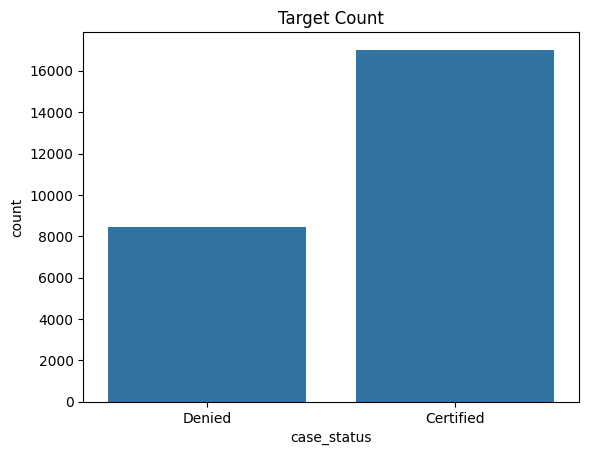

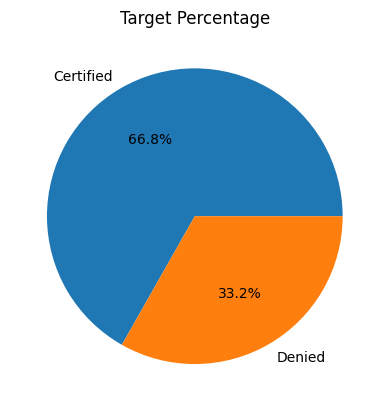

In [29]:
# 4.1 Target Distribution 

# Count plot
sns.countplot(x=TARGET_COL, data=df)
plt.title("Target Count")
plt.show()

# Pie chart
target_counts = df[TARGET_COL].value_counts()
plt.pie(target_counts, labels=target_counts.index, autopct='%1.1f%%')
plt.title("Target Percentage")
plt.show()


In [30]:
# elif PROBLEM_TYPE == 'regression':
#     # Skewness
#     skewness = df[TARGET_COL].skew()
#     print("Skewness:", round(skewness, 2))

#     # Histogram
#     sns.histplot(df[TARGET_COL], kde=True)
#     plt.title("Distribution")
#     plt.show()

#     # Boxplot
#     sns.boxplot(y=df[TARGET_COL])
#     plt.title("Boxplot")
#     plt.show()

#     # Check skew
#     if abs(skewness) > 0.5:
#         print("Data is skewed → use log transform")

---
## Section 5: Univariate Analysis — One Feature at a Time
**What:** Look at each feature independently, without comparing to target.

**Why:** Understand each feature's distribution. Spot:
- Skewed distributions → apply transformation
- Imbalanced categories → group rare ones into Other
- Outliers (visually)

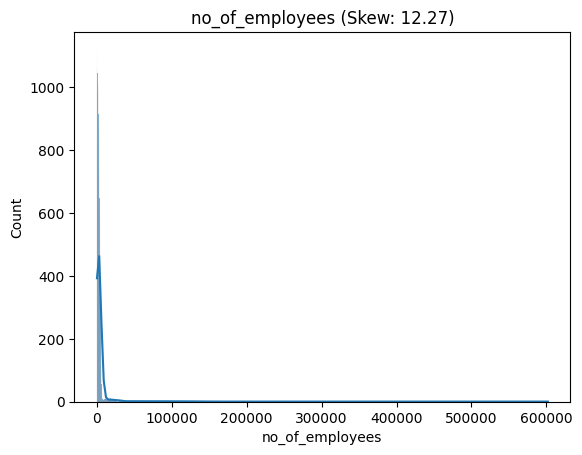

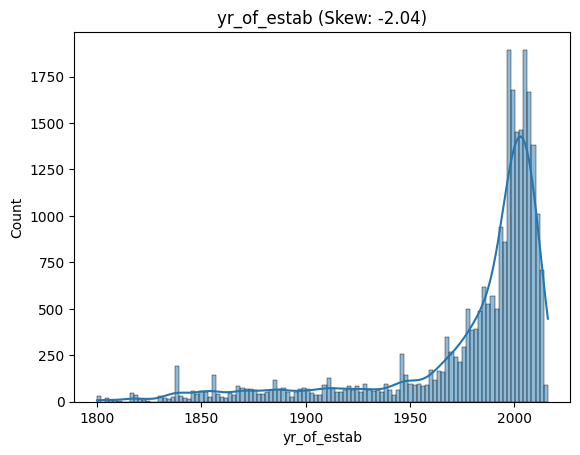

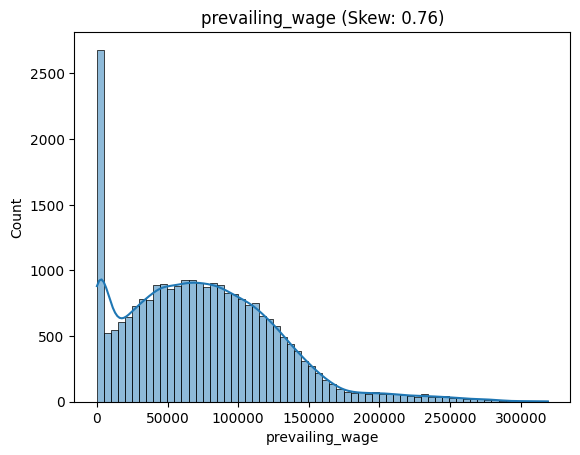

In [31]:
# 5.1 Numerical Features — Distribution (Histogram + KDE) 
# KDE = Kernel Density Estimate → smooth version of histogram
# Shapes to look for:
#   Bell-shaped     → Normal distribution → ideal for many models
#   Right-skewed    → Long tail on right  → apply log transform
#   Left-skewed     → Long tail on left   → apply sqrt or square transform
#   Bimodal (2 peaks) → May represent two subgroups in data


num_cols = [col for col in numerical_features if col != TARGET_COL]

# Plot one by one
for col in num_cols:
    skew_val = df[col].skew()
    
    sns.histplot(df[col], kde=True)
    plt.title(f"{col} (Skew: {round(skew_val, 2)})")
    plt.show()

In [32]:
# 5.2 Skewness Summary Table 
# Rule of thumb:
#   |skew| < 0.5   → Symmetric   → Good, no transform needed
#   |skew| 0.5–1   → Moderate    → Optional: try log,sqrt transform
#   |skew| > 1     → High skew   → Apply log1p or Box-Cox transform

skew_list = []

for col in num_cols:
    skew_val = round(df[col].skew(), 3)
    
    if abs(skew_val) < 0.5:
        status = "Normal"
    elif abs(skew_val) < 1:
        status = "Moderate Skew"
    else:
        status = "High Skew"
    
    skew_list.append([col, skew_val, status])

skew_df = pd.DataFrame(skew_list, columns=["Feature", "Skewness", "Status"])

In [33]:
skew_df

,Feature,Skewness,Status
0,no_of_employees,12.27,High Skew
1,yr_of_estab,-2.04,High Skew
2,prevailing_wage,0.76,Moderate Skew


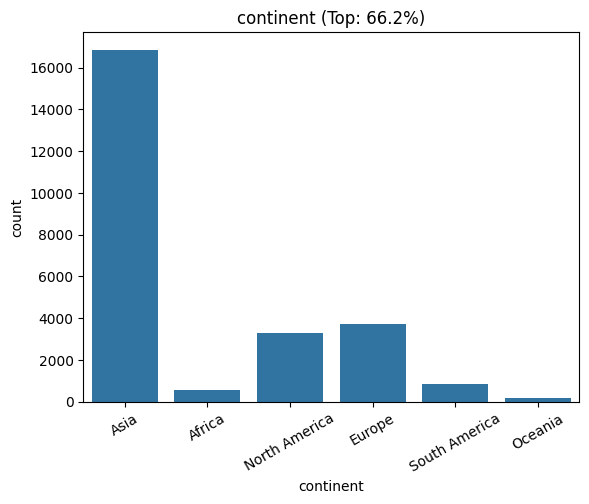

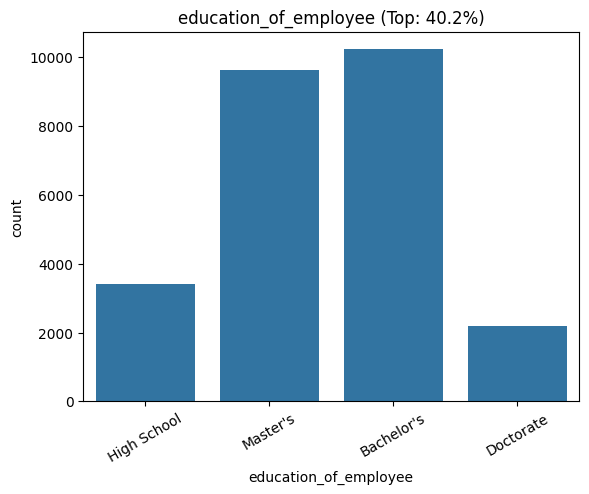

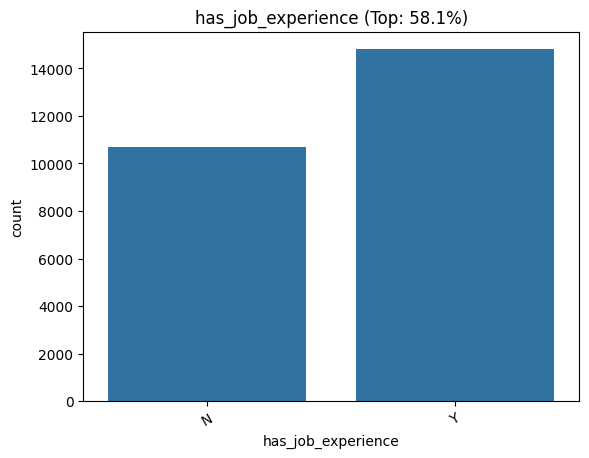

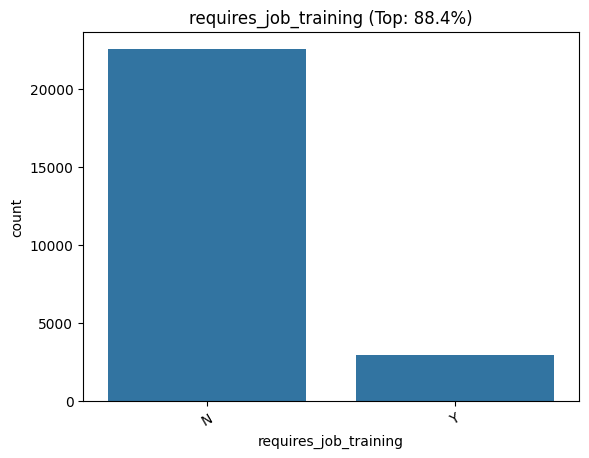

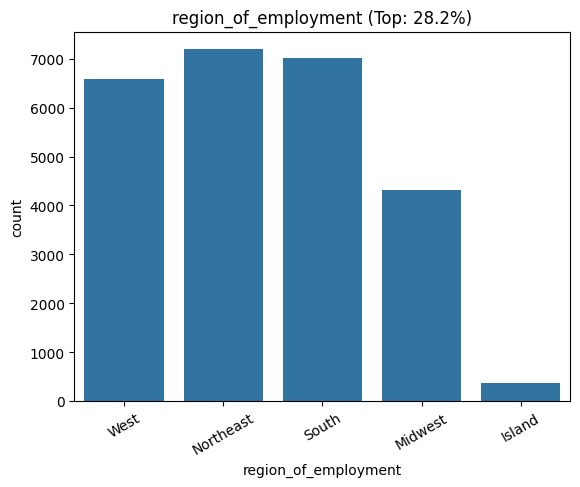

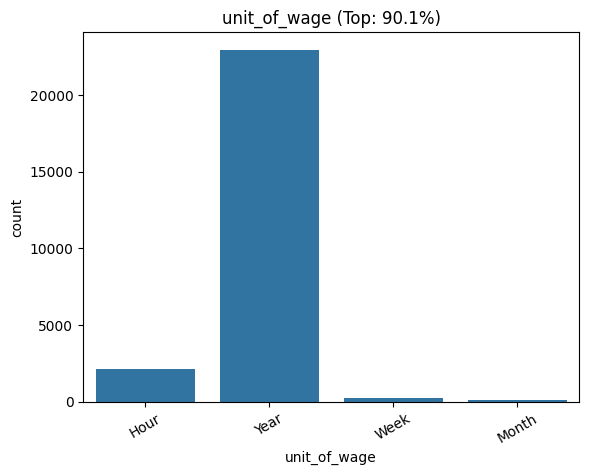

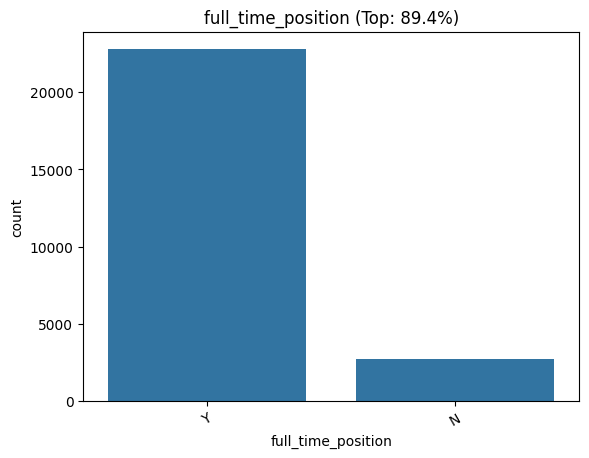

In [34]:
# 5.3 Categorical Features — Count Plots 
# Watch for:
#   One dominant category (>80%)     → Imbalanced → group rare ones into 'Other'
#   Many unique values (>15 cats)    → High cardinality → use frequency or target encoding

# Skip ID columns - plotting/testing 25k unique values is meaningless
cat_cols_to_plot = [col for col in categorical_features if col != TARGET_COL and col not in id_cols]

for col in cat_cols_to_plot:
    val_counts = df[col].value_counts()
    top_pct = (val_counts.iloc[0] / len(df)) * 100
    
    sns.countplot(x=col, data=df)
    plt.title(f"{col} (Top: {round(top_pct, 1)}%)")
    plt.xticks(rotation=30)
    plt.show()



In [ ]:
#  5.4 Categorical Proportions Table 
# Numbers are more precise than charts. Use this to check exact distribution.
for col in cat_cols_to_plot:
    print("\nColumn:", col)
    
    percentages = df[col].value_counts(normalize=True) * 100
    print(percentages.round(2))


Column: continent
continent
Asia            66.17
Europe          14.65
North America   12.92
South America    3.34
Africa           2.16
Oceania          0.75
Name: proportion, dtype: float64

Column: education_of_employee
education_of_employee
Bachelor's    40.16
Master's      37.81
High School   13.42
Doctorate      8.60
Name: proportion, dtype: float64

Column: has_job_experience
has_job_experience
Y   58.09
N   41.91
Name: proportion, dtype: float64

Column: requires_job_training
requires_job_training
N   88.40
Y   11.60
Name: proportion, dtype: float64

Column: region_of_employment
region_of_employment
Northeast   28.24
South       27.54
West        25.85
Midwest     16.90
Island       1.47
Name: proportion, dtype: float64

Column: unit_of_wage
unit_of_wage
Year    90.12
Hour     8.47
Week     1.07
Month    0.35
Name: proportion, dtype: float64

Column: full_time_position
full_time_position
Y   89.38
N   10.62
Name: proportion, dtype: float64


---
## Section 6: Outlier Detection

**Why this matters for ML:**
- Tree models (RF, XGBoost) → NOT sensitive to outliers 
- Linear/Logistic Regression, KNN, SVM → VERY sensitive 

**Two methods:**
1. **Visual** → Boxplot (dots beyond whiskers = outliers)
2. **Statistical** → IQR method (values outside Q1-1.5×IQR or Q3+1.5×IQR)

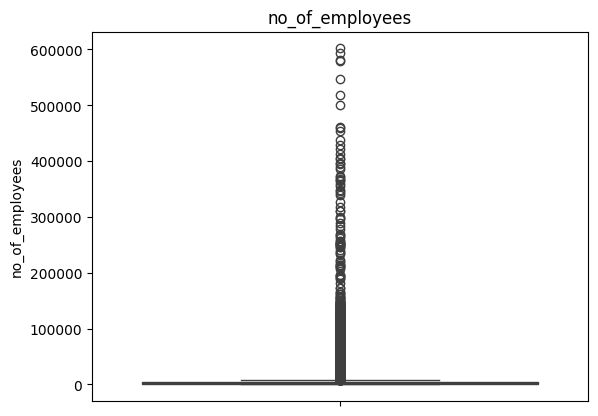

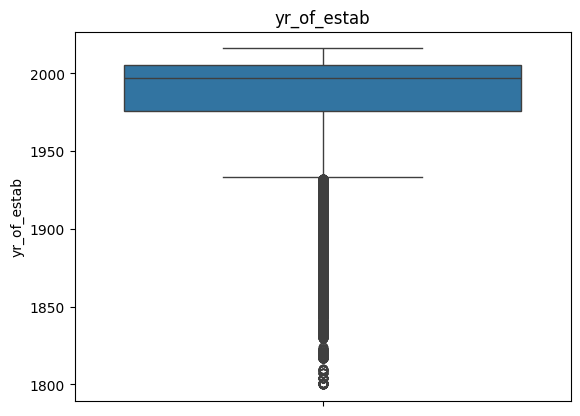

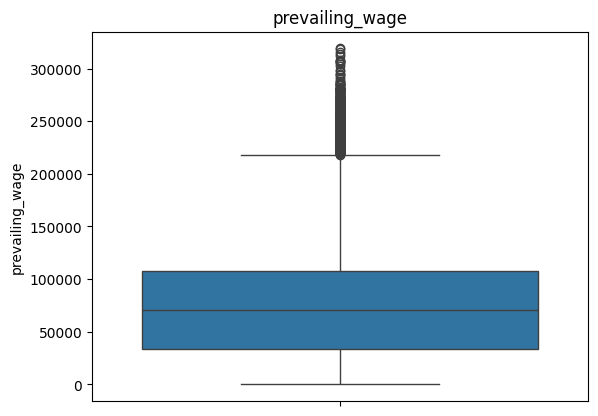

In [36]:
# 6.1 Boxplots for Numerical Features
for col in continuous_features:
    sns.boxplot(y=df[col], orient="h")
    plt.title(col)
    plt.show()

In [37]:
# 6.2 IQR Outlier Count Table 
# IQR = Q3 - Q1
# Lower Fence = Q1 - 1.5 × IQR  (values below = lower outliers)
# Upper Fence = Q3 + 1.5 × IQR  (values above = upper outliers)
#
# What to do with outliers (decide in Feature Engineering):
#   < 5%  → Cap them (Winsorize) at 1st/99th percentile
#   > 5%  → Investigate — may be real data, may need log transform
#   Negative values for non-negative features → Data entry error, fix/remove

outlier_list = []

for col in continuous_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df[col] < lower) | (df[col] > upper)).sum()
    pct = (count / len(df)) * 100

    if pct < 5:
        action = "Cap"
    else:
        action = "Investigate"

    outlier_list.append([col, round(pct, 2), action])

outlier_df = pd.DataFrame(outlier_list, columns=["Column", "Outlier %", "Action"])
print(outlier_df)

            Column  Outlier %       Action
0  no_of_employees       6.11  Investigate
1      yr_of_estab      12.79  Investigate
2  prevailing_wage       1.68          Cap


---
## Section 7: Bivariate & Multivariate Analysis
**What:** Analyze the relationship between each feature and the target.

**Why:** Find which features actually influence visa approval.  
This is the most important part — it tells you what to keep and what to drop.


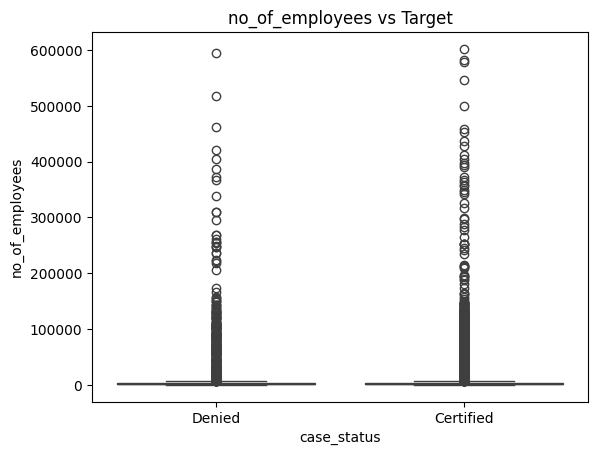

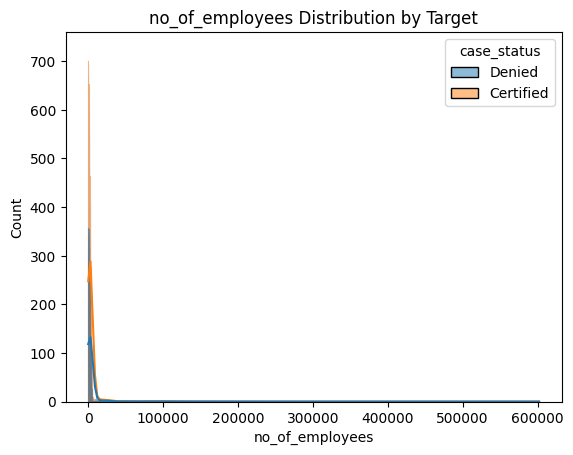

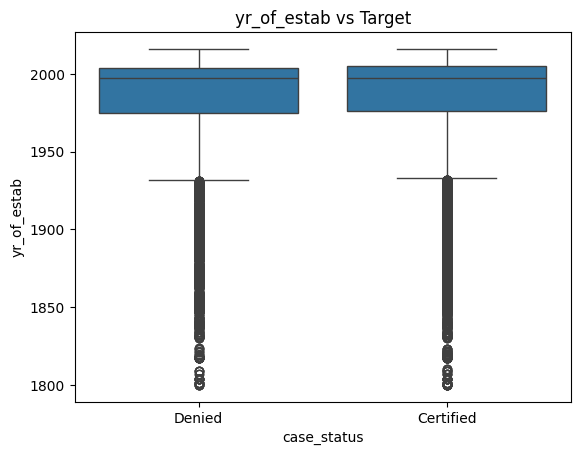

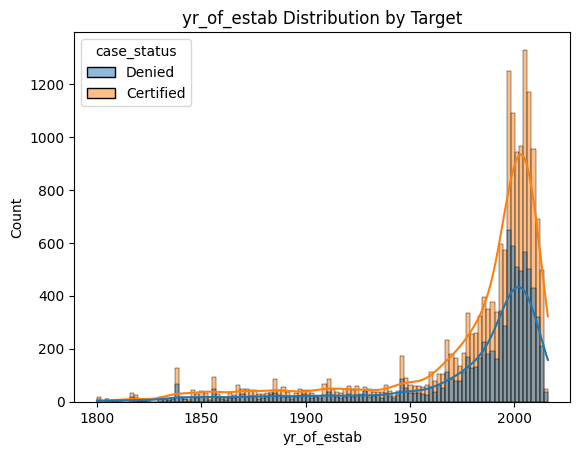

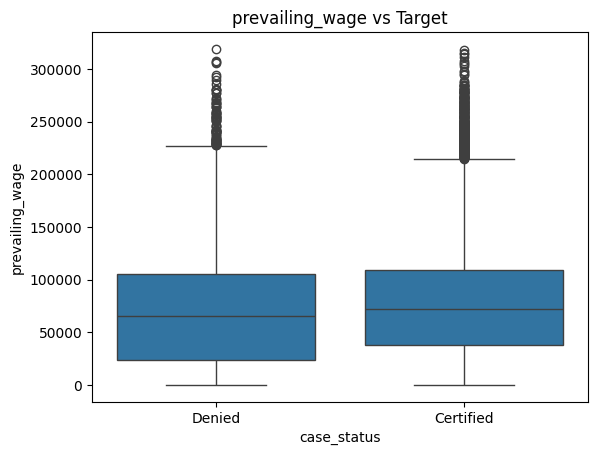

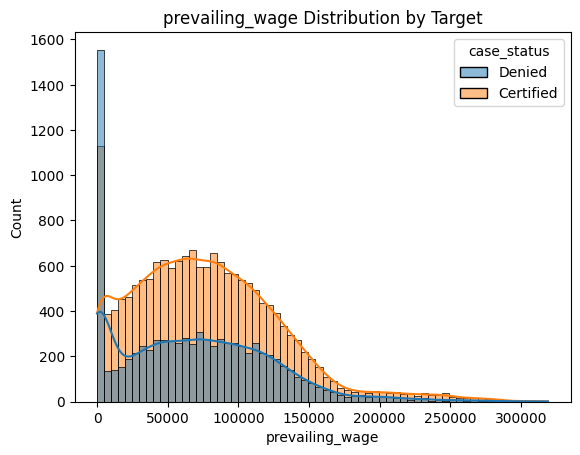

In [38]:
# 7.1 Numerical Features vs Target (Boxplot + Distribution by Class) 
# For Classification:
#   - Boxplot per class: if distributions DIFFER → feature is useful
#   - If distributions OVERLAP completely → feature may not help the model
#
# For Regression:
#   - Scatter plot: if pattern/trend exists → feature is useful
#   - Random scatter with no pattern → feature may not help

if PROBLEM_TYPE == 'classification':
    for col in continuous_features:
        if col == TARGET_COL:
            continue
        
        # Boxplot
        sns.boxplot(x=TARGET_COL, y=col, data=df)
        plt.title(f"{col} vs Target")
        plt.show()

        # Distribution
        sns.histplot(data=df, x=col, hue=TARGET_COL, kde=True)
        plt.title(f"{col} Distribution by Target")
        plt.show()

In [39]:
from scipy.stats import mannwhitneyu

for col in continuous_features:
    if col != TARGET_COL:
        grp1 = df[df[TARGET_COL] == 'Certified'][col]
        grp2 = df[df[TARGET_COL] == 'Denied'][col]
        
        stat, p = mannwhitneyu(grp1, grp2)
        print(f"{col}: p-value = {p}")

no_of_employees: p-value = 2.4051433302565357e-06
yr_of_estab: p-value = 0.0007957749239807266
prevailing_wage: p-value = 3.134782478720992e-39


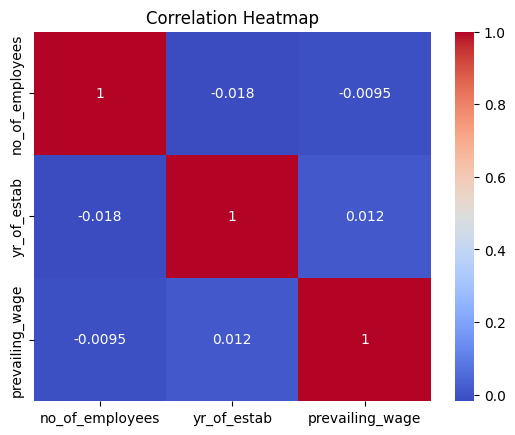

In [40]:
#  Numerical Correlation Heatmap
# Correlation values:
#   > +0.85  → Strong positive → features move together → drop one
#   < -0.85  → Strong negative → as one goes up, other goes down → drop one
#   Near 0   → No linear relationship → both can stay
#
# Note: Heatmap shows only lower triangle to avoid duplication.

num_df = df.select_dtypes(include='number')

# Correlation matrix
corr = num_df.corr()

# Heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Check high correlation
for col1 in corr.columns:
    for col2 in corr.columns:
        if col1 != col2:
            val = corr.loc[col1, col2]
            if abs(val) > 0.85:
                print(col1, "-", col2, ":", round(val, 2))

In [41]:
# if PROBLEM_TYPE == 'regression':
#     for col in continuous_features:
#         if col == TARGET_COL:
#             continue
        
#         plt.scatter(df[col], df[TARGET_COL])
#         plt.xlabel(col)
#         plt.ylabel(TARGET_COL)
#         plt.title(f"{col} vs Target")
#         plt.show()

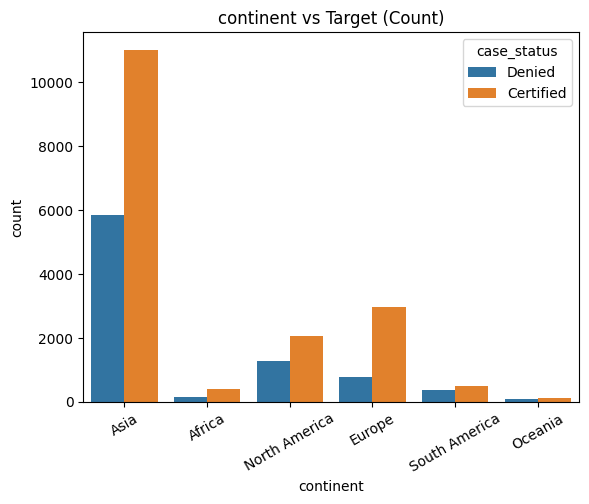

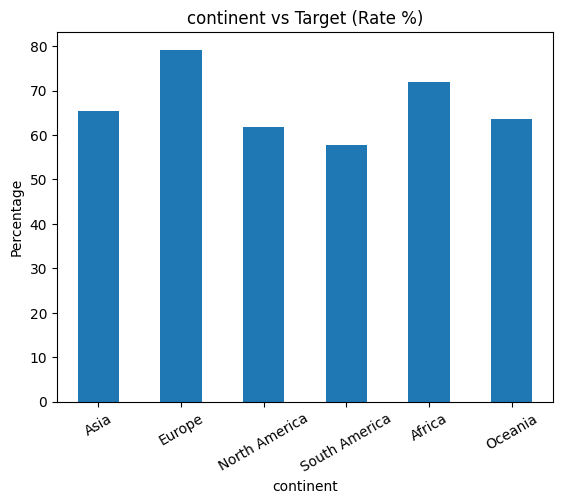

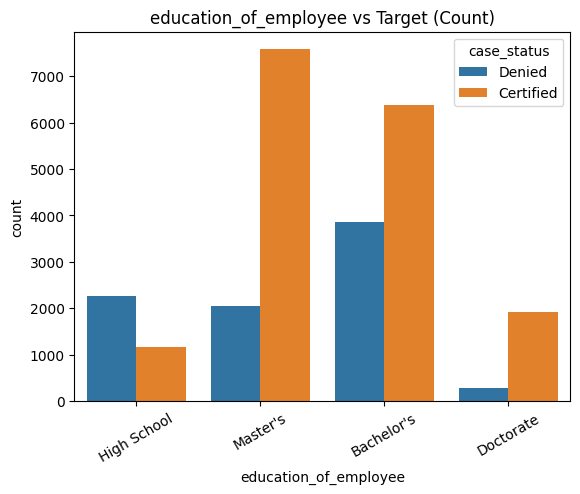

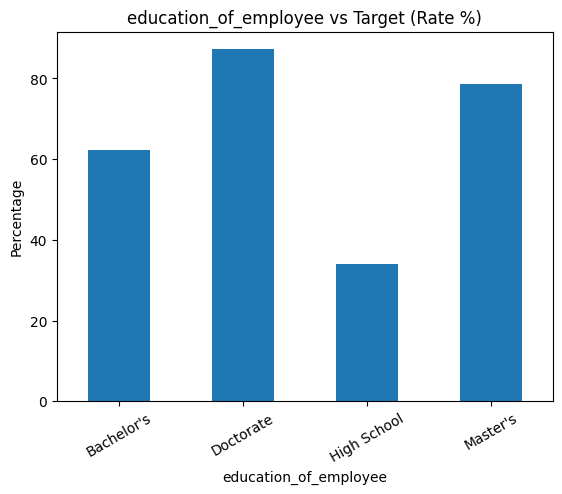

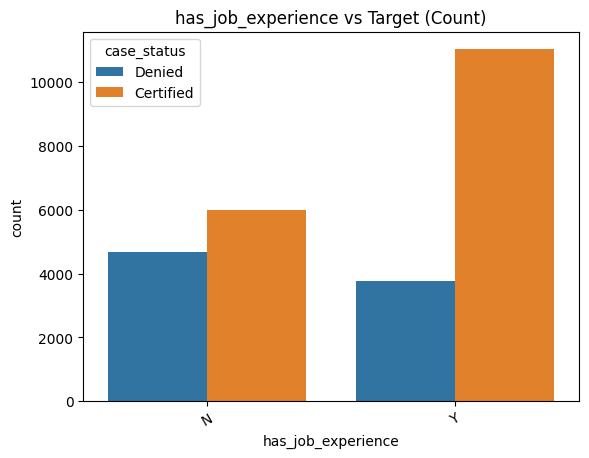

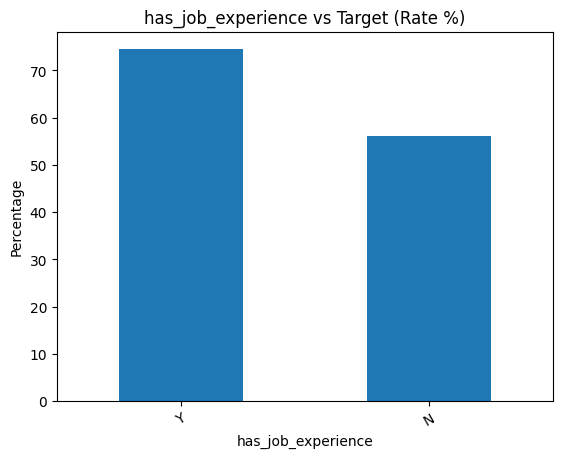

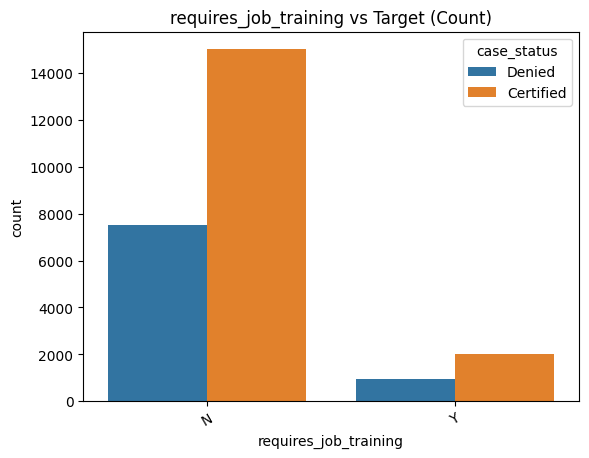

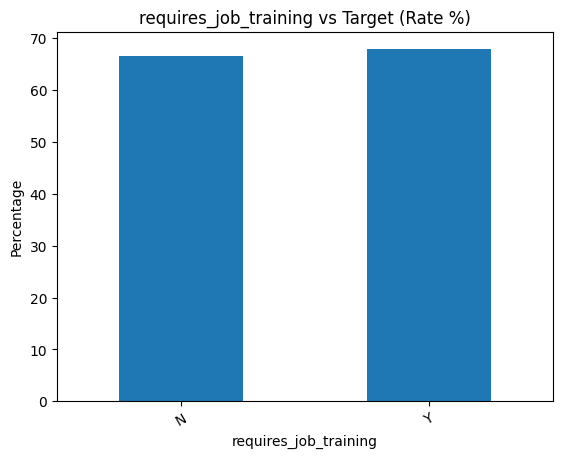

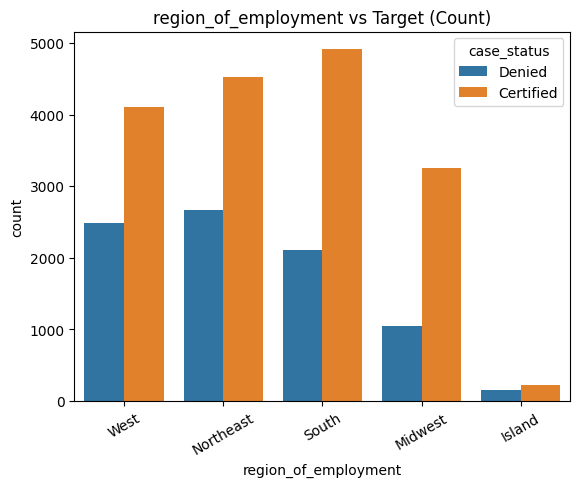

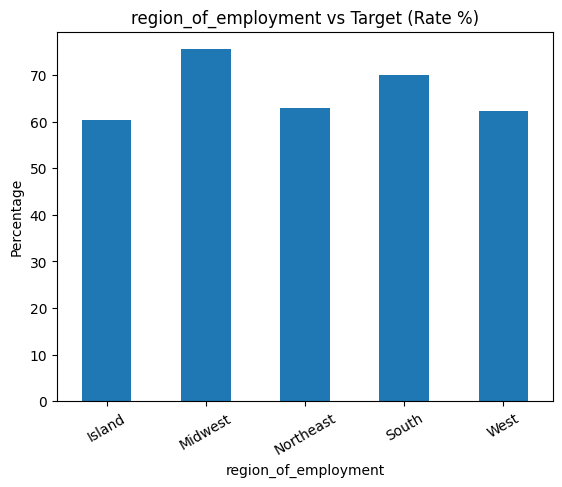

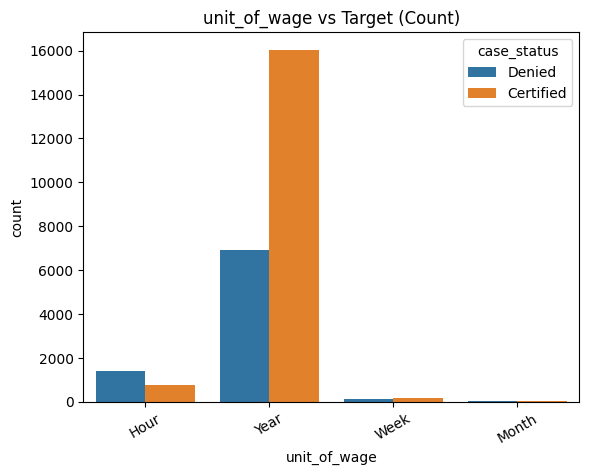

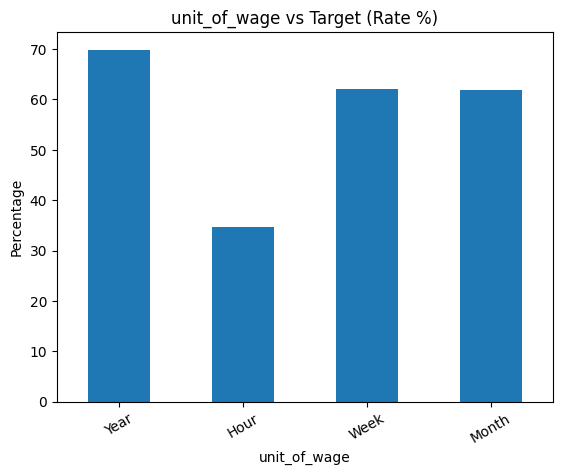

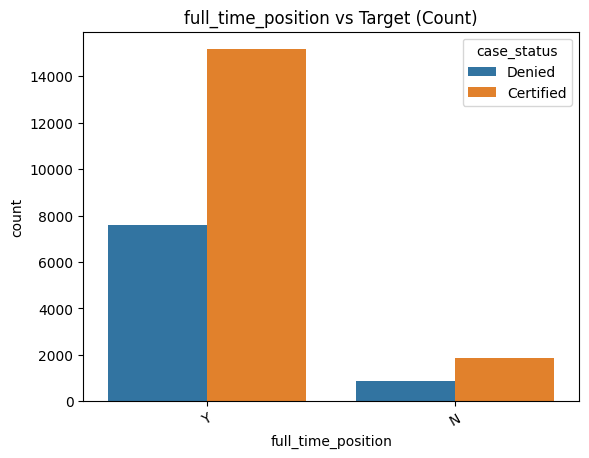

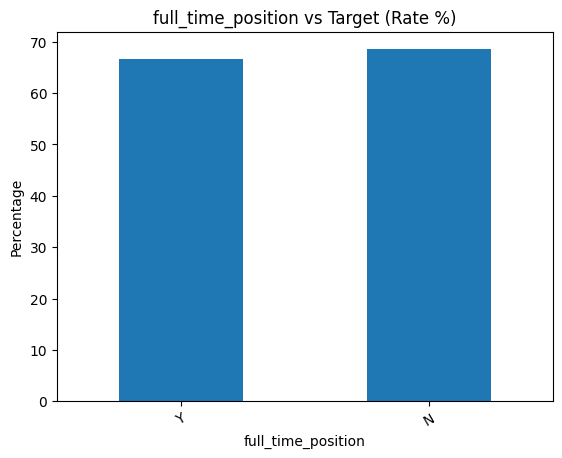

In [42]:
# 7.2 Categorical Features vs Target (Count + Approval Rate)
# Two charts per feature:
#   1. Count Plot    → raw counts per category (absolute view)
#   2. Rate Bar Plot → % of positive class per category (relative view ← more useful)
#
# Example: If "Education=Masters" has 80% approval rate vs "High School" at 40%
#          → Education is clearly important for the model

if PROBLEM_TYPE == 'classification':
    target_positive = df[TARGET_COL].value_counts().index[0]

    for col in cat_cols_to_plot:
        if col == TARGET_COL:
            continue

        # Count plot
        sns.countplot(x=col, hue=TARGET_COL, data=df)
        plt.title(f"{col} vs Target (Count)")
        plt.xticks(rotation=30)
        plt.show()

        # Rate (%)
        rate = (df[df[TARGET_COL] == target_positive][col].value_counts() /
                df[col].value_counts()) * 100

        rate.plot(kind='bar')
        plt.title(f"{col} vs Target (Rate %)")
        plt.ylabel("Percentage")
        plt.xticks(rotation=30)
        plt.show()

In [43]:
# Chi-Square Test — Categorical Features vs Target 
# Only for classification problems.
# LOGIC:
#   Null Hypothesis (H₀) : Feature is INDEPENDENT of target (not useful)
#   Alt  Hypothesis (H₁) : Feature is RELATED to target  (useful)
#
# Decision Rule:
#   p-value < 0.05 → Reject H₀ → Feature IS related to target → KEEP
#   p-value ≥ 0.05 → Fail to reject H₀ → Feature NOT related  → Consider DROP
#
# Think of p-value as: "probability this relationship is just random chance"
# Low p-value → not random → real relationship exists

results = []

for col in cat_cols_to_plot:
    
    if col == TARGET_COL:
        continue
    
    table = pd.crosstab(df[TARGET_COL], df[col])
    chi2, p, _, _ = chi2_contingency(table)

    if p < 0.05:
        status = "Related (Keep)"
    else:
        status = "Not Related (Drop)"
    
    results.append([col, round(p, 5), status])

chi_df = pd.DataFrame(results, columns=["Feature", "p-value", "Result"])
print(chi_df)
print("Chi-Square Test Results (Categorical Features vs Target):")
display(chi_df)

                 Feature  p-value              Result
0              continent     0.00      Related (Keep)
1  education_of_employee     0.00      Related (Keep)
2     has_job_experience     0.00      Related (Keep)
3  requires_job_training     0.19  Not Related (Drop)
4   region_of_employment     0.00      Related (Keep)
5           unit_of_wage     0.00      Related (Keep)
6     full_time_position     0.04      Related (Keep)
Chi-Square Test Results (Categorical Features vs Target):


,Feature,p-value,Result
0,continent,0.00,Related (Keep)
1,education_of_employee,0.00,Related (Keep)
2,has_job_experience,0.00,Related (Keep)
3,requires_job_training,0.19,Not Related (Drop)
4,region_of_employment,0.00,Related (Keep)
5,unit_of_wage,0.00,Related (Keep)
6,full_time_position,0.04,Related (Keep)


---
## Section 8: Final EDA Report & Feature Engineering Plan.

> The code below auto-generates a quick summary.  
> Then review the manual notes table below with EasyVisa-specific observations.

In [44]:
# 8.1 Auto-Generated EDA Summary 
print("EDA SUMMARY")

# Basic info
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Target:", TARGET_COL)

# Missing & duplicates
print("Missing values:", df.isnull().sum().sum())
print("Duplicates:", df.duplicated().sum())

# Column types
print("Numerical:", numerical_features)
print("Categorical:", categorical_features)

# Skewed features
for col in num_cols:
    if abs(df[col].skew()) > 1:
        print("Skewed:", col)

# ID & constant columns
for col in df.columns:
    if df[col].nunique() == len(df):
        print("ID column:", col)
    elif df[col].nunique() == 1:
        print("Constant column:", col)


EDA SUMMARY
Rows: 25480
Columns: 12
Target: case_status
Missing values: 0
Duplicates: 0
Numerical: ['no_of_employees', 'yr_of_estab', 'prevailing_wage']
Categorical: ['case_id', 'continent', 'education_of_employee', 'has_job_experience', 'requires_job_training', 'region_of_employment', 'unit_of_wage', 'full_time_position', 'case_status']
Skewed: no_of_employees
Skewed: yr_of_estab
ID column: case_id


---
## 📝 EasyVisa EDA Notes — Feature Engineering Plan

### Feature-by-Feature Action Plan

| Column | Finding | Action in Feature Engineering |
|--------|---------|-------------------------------|
| case_id | ID column — unique per row | **DROP** |
| continent | 6 categories, Asia dominates | **One-Hot Encode** |
| education_of_employee | 4 levels — ordinal meaning | **Ordinal Encode (High School < Bachelor's < Master's < Doctorate)** |
| has_job_experience | Binary Y/N | **Label Encode (0/1)** |
| requires_job_training | No significant impact on target | **DROP** |
| no_of_employees | Has negative values; highly skewed | **Fix negatives → abs; apply log1p()** |
| yr_of_estab | Year feature — older vs newer companies matter | **Engineer: company_age = current_year - yr_of_estab** |
| region_of_employment | 5 US regions | **One-Hot Encode** |
| prevailing_wage | Highly skewed; mixed units | **Normalize using unit_of_wage → annual; then log1p()** |
| unit_of_wage | Provides job-type information (hourly vs salaried) | **One-Hot Encode (retain feature)** |
| full_time_position | Weak practical impact | **Label Encode (0/1)** |

---

### Target Variable Summary
- **Imbalanced?** → Certified ~67%, Denied ~33% → Mild imbalance  
  → Action: Use **class_weight='balanced'** in model; monitor **Recall for Denied class**

---

### Key Business Insights

1. **Education matters 🔥**  
   Higher education (Master’s, Doctorate) significantly increases visa approval chances.

2. **Job experience matters**  
   Applicants with prior experience have higher approval probability.

3. **Prevailing wage is the strongest factor**  
   Higher salary → higher approval rate; must normalize wage units before modeling.

4. **Company size has limited impact**  
   Number of employees is not a strong predictor despite statistical significance.

5. **Geography plays a moderate role**  
   Continent and region show some variation in approval rates.

6. **Hourly jobs are less likely to be approved**  
   Wage type (hourly vs salaried) influences approval decisions.

7. **Some features have negligible impact**  
   Job training requirement shows no significant impact on outcomes.

---

### ⚠️ Important Notes

- Outliers in numerical features are **natural (not errors)** → handled using **log transformation**
- Statistical tests used:
  - Numerical → **Mann-Whitney U**
  - Categorical → **Chi-Square**
- Feature selection based on:
  - ✔ Statistical significance  
  - ✔ Visual patterns  
  - ✔ Business understanding  
- Although `unit_of_wage` was used for wage normalization, it is retained as a categorical feature to capture additional job-type information.

---

> **Remember:** EDA is not just analysis — every finding here must map to a specific  
> transformation, drop, or encoding step in your Feature Engineering notebook.
---